
<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 1
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consignas

## Ejercicio 1

Sintetizar:
- Señal sinusoidal de 2KHz
- Misma señal amplificada y desfazada en $\frac{\pi}{2}$
- Misma señal modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia
- Señal anterior recortada al 75% de su amplitud
- Una señal cuadrada de 4KHz
- Un pulso rectangular de 10ms

En cada caso indique tiempo entre muestras, número de muestras y potencia o energía según corresponda

## Ejercio 2

Dado $h[n] = \delta[n] - \delta[n - 4]$, encontrar $y[n] = x[n] * h[n]$ para cada una de las siguientes $x[n]$:

a) $x[n] = cos(w_{0}.n.T_{s})$. Expresar la respuesta como un único coseno de la forma $A . cos(w_{0}.n.T_{s} + \phi)$.

b) $x[n] = (1/2)^n . u[n]$

c) $x[n] = u[n + 1] - u[n - 2]$

## Resolución ejercicio 1
### Definición de funciones

A continuación se presentan las definiciones de las funciones utilizadas a lo largo de este trabajo

In [1]:
import numpy as np

# función para sintetizar señales senoidales.
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):

    # tiempo de muestreo
    ts = 1/fs
    
    # vector de tiempo
    tt = np.linspace(0, (nn-1)*ts, nn)
    
    # señal senoidal
    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    
    return tt, xx

# función para calular la potencia media de una señal.
def potencia_media(xx):
    pp = np.mean(xx ** 2)
    return pp

# función para calular la energía de una señal.
def energia(xx, ts):
    ee = np.sum(xx ** 2) * ts
    return ee

### Señal sinusiodal de 2KHz

── Señal 1: Sinusoide 2 kHz ──────────────────
  Δt         = 20.0000 µs
  N muestras = 250
  Duración   = 5.00 ms
  Potencia   = 0.500000 W 


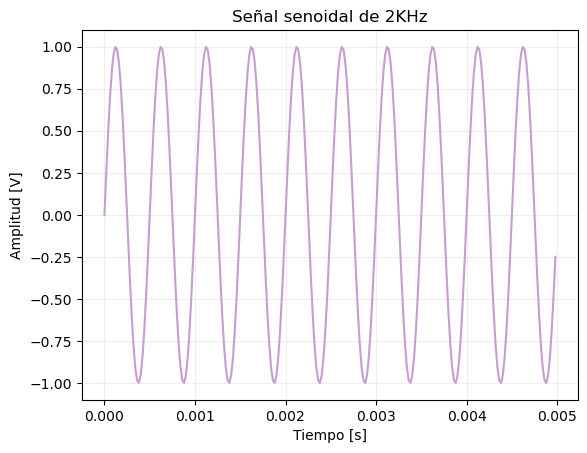

In [2]:
import matplotlib.pyplot as plt

FS = 50000          # Nyquist fs >>= 2*ff
TS = 1 / FS         # tiempo entre muestras

ff1 = 2000
N1  = int(10 / ff1 * FS)   # 10 ciclos de 2kHz → 250 muestras

tt1, xx1 = mi_funcion_sen(vmax=1, dc=0, ff=ff1, ph=0, nn=N1, fs=FS)  # nn=N1, no nn=N
P1 = potencia_media(xx1)

print("── Señal 1: Sinusoide 2 kHz ──────────────────")
print(f"  Δt         = {TS*1e6:.4f} µs")
print(f"  N muestras = {N1}")
print(f"  Duración   = {N1*TS*1e3:.2f} ms")
print(f"  Potencia   = {P1:.6f} W ")

plt.plot(tt1, xx1, color='#C69DD2')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal de 2KHz")
plt.grid(True, alpha=0.2)
plt.show()

### Misma señal amplificada y desfazada en $\pi / 2$


── Señal 2: Amplificada ×2 y desfasada π/2 ───
  Δt          = 20.0000 µs
  N muestras  = 250
  Duración    = 5.00 ms
  Potencia    = 2.000000 W 


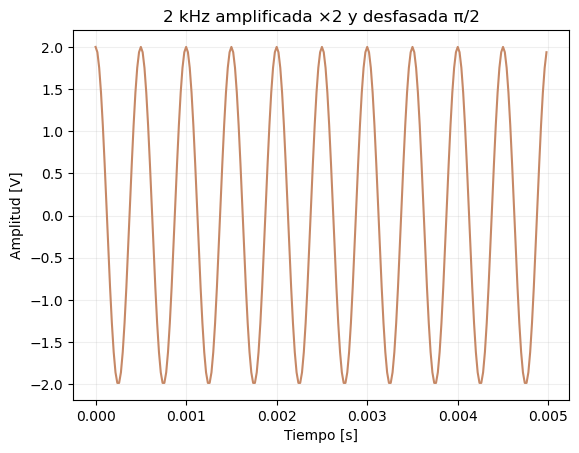

In [3]:
ff2   = 2000
vmax2 = 2
ph2   = np.pi / 2
N2    = N1   # misma duración
tt2, xx2 = mi_funcion_sen(vmax=vmax2, dc=0, ff=ff2, ph=ph2, nn=N2, fs=FS)
 
P2 = potencia_media(xx2)
print("\n── Señal 2: Amplificada ×2 y desfasada π/2 ───")
print(f"  Δt          = {TS*1e6:.4f} µs")
print(f"  N muestras  = {N2}")
print(f"  Duración    = {N2*TS*1e3:.2f} ms")
print(f"  Potencia    = {P2:.6f} W ")

plt.plot(tt2, xx2,color='#C68866')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("2 kHz amplificada ×2 y desfasada π/2")
plt.grid(True, alpha=0.2)

plt.show()

A continuación se grafican las formas de onda de ambas señales para su comparación: la señal original a 2 kHz y la señal modificada, cuya amplitud es el doble de la original y presenta un avance de fase de $\pi/2$ (equivalente a 90 grados).

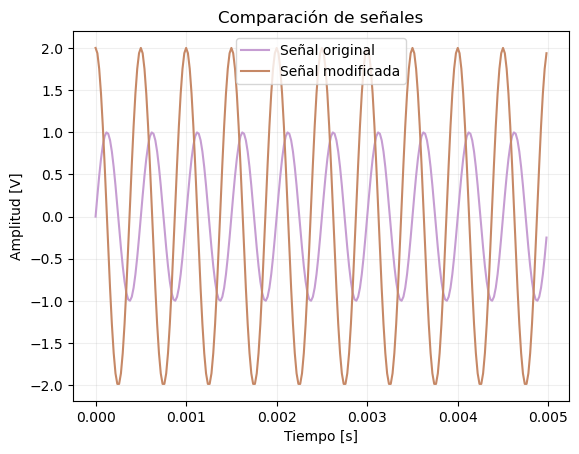

In [4]:

plt.plot(tt1, xx1,color='#C69DD2', label = 'Señal original')
plt.plot(tt2, xx2,color='#C68866', label = 'Señal modificada')
plt.legend()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Comparación de señales")
plt.grid(True, alpha=0.2)

plt.show()

### Misma señal modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia

── Señal 3: AM+ (portadora 2kHz, moduladora 1kHz) ──
  Índice de modulación m = 1
  Δt         = 20.0000 µs
  N muestras = 500
  Duración   = 10.00 ms
  Potencia   = 0.750000 W 


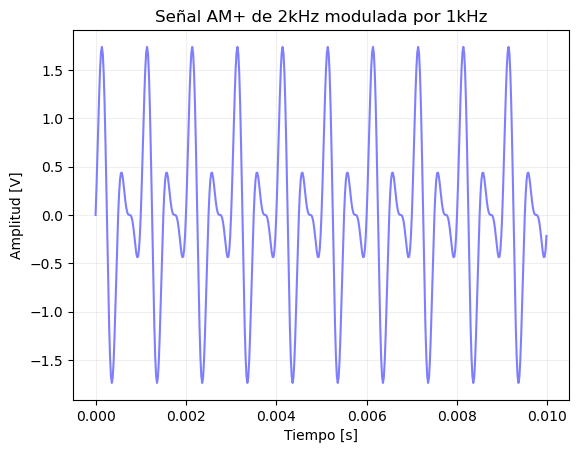

In [5]:
import matplotlib.pyplot as plt

ff_portadora  = 2000
ff_moduladora = 1000   # mitad de la portadora
m = 1                  # índice de modulación (0 < m <= 1 para no sobremodular)

N3 = int(10 / ff_moduladora * FS)   # 10 ciclos de la señal más lenta

tt3, portadora   = mi_funcion_sen(vmax=1, dc=0, ff=ff_portadora,  ph=0, nn=N3, fs=FS)
tt3,  moduladora  = mi_funcion_sen(vmax=1, dc=0, ff=ff_moduladora, ph=0, nn=N3, fs=FS)

# AM+: envolvente nunca cruza cero → sin sobremodulación
xx3 = (1 + m * moduladora) * portadora

P3 = potencia_media(xx3)

print("── Señal 3: AM+ (portadora 2kHz, moduladora 1kHz) ──")
print(f"  Índice de modulación m = {m}")
print(f"  Δt         = {TS*1e6:.4f} µs")
print(f"  N muestras = {N3}")
print(f"  Duración   = {N3*TS*1e3:.2f} ms")
print(f"  Potencia   = {P3:.6f} W ")

plt.plot(tt3, xx3, color='#7F7EFF')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal AM+ de 2kHz modulada por 1kHz")
plt.grid(True, alpha=0.2)
plt.show()

Gráfico comparativo de señales: se muestra la señal portadora de 2 kHz (violeta) frente a la señal modulada en amplitud por una senoidal de 1 kHz (azul). La representación permite verificar el efecto de la modulación sobre la amplitud de la portadora a lo largo del tiempo.

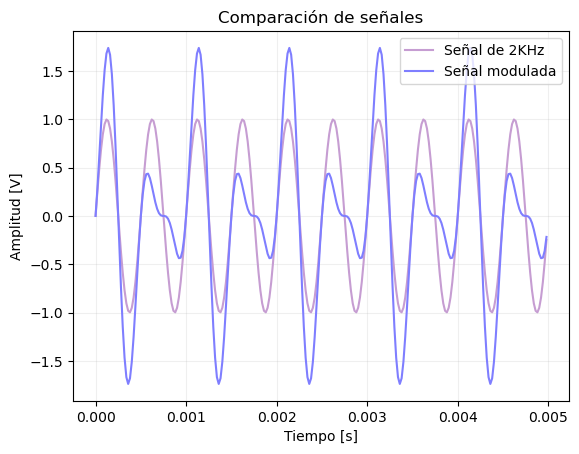

In [6]:
# Recortar xx3 a la misma duración que xx1
N_comparar = len(tt1)
tt_comp = tt1                    # mismo eje de tiempo
xx3_comp = xx3[:N_comparar]      # recortar la señal modulada

plt.plot(tt_comp, xx1,color='#C69DD2', label = 'Señal de 2KHz')
plt.plot(tt_comp, xx3_comp,color='#7F7EFF', label = 'Señal modulada')
plt.legend()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Comparación de señales")
plt.grid(True, alpha=0.2)

plt.show()

**Extra**: Aunque la consigna establece que la señal modulante debe tener la mitad de la frecuencia que la portadora, para poder visualizar correctamente el efecto de la modulación es necesario que la portadora posea una frecuencia significativamente mayor. Por este motivo, en el siguiente gráfico se presenta el resultado de la modulación utilizando una señal modulante con una frecuencia diez veces menor a la portadora.

── Señal AM+ : portadora 2kHz, moduladora 200Hz ──
  Índice de modulación m = 1
  Δt         = 20.0000 µs
  N muestras = 2500
  Duración   = 50.00 ms
  Potencia   = 0.750000 W  (teórico: 0.750000 W)


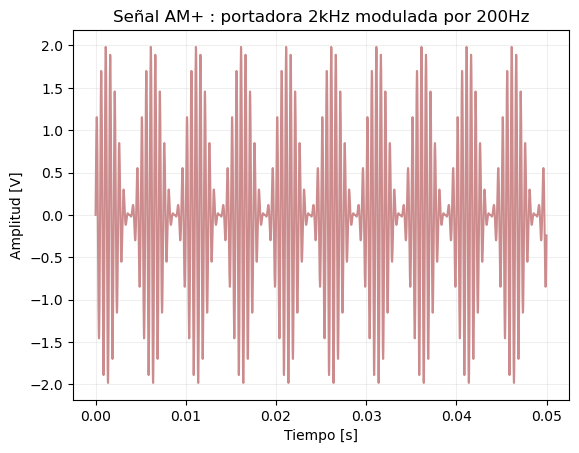

In [7]:

ff_portadora  = 2000
ff_moduladora = 200    # 10 veces menor que la portadora
m = 1                  # índice de modulación

N3b = int(10 / ff_moduladora * FS)   # 10 ciclos de la señal más lenta

tt, portadora  = mi_funcion_sen(vmax=1, dc=0, ff=ff_portadora,  ph=0, nn=N3b, fs=FS)
tt, moduladora = mi_funcion_sen(vmax=1, dc=0, ff=ff_moduladora, ph=0, nn=N3b, fs=FS)

xx3b = (1 + m * moduladora) * portadora

P3b = potencia_media(xx3b)

print("── Señal AM+ : portadora 2kHz, moduladora 200Hz ──")
print(f"  Índice de modulación m = {m}")
print(f"  Δt         = {TS*1e6:.4f} µs")
print(f"  N muestras = {N3b}")
print(f"  Duración   = {N3b*TS*1e3:.2f} ms")
print(f"  Potencia   = {P3b:.6f} W  (teórico: {0.5*(1 + m**2/2):.6f} W)")

plt.plot(tt, xx3b, color='#CC8B8C')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal AM+ : portadora 2kHz modulada por 200Hz")
plt.grid(True, alpha=0.2)
plt.show()

### Señal anterior recortada al 75% de su amplitud

Para esta parte de la consigna se utilizó la función *np.clip* de la biblioteca NumPy. Esta herramienta permite limitar (o acotar) los valores de un arreglo dentro de un rango definido. Es decir, los datos que caen fuera de este límite se ajustan a los extremos del mismo. Por ejemplo, si se establece el intervalo [0, 1], cualquier valor menor a 0 adopta el valor 0, y cualquier valor mayor a 1 se convierte en 1.


── Señal 4: AM recortada al 75 % (clipping) ──────
  Δt          = 20.0000 µs
  N muestras  = 500  (misma duración que señal 3)
  Duración    = 10.00 ms
  Potencia    = 0.256881 W 


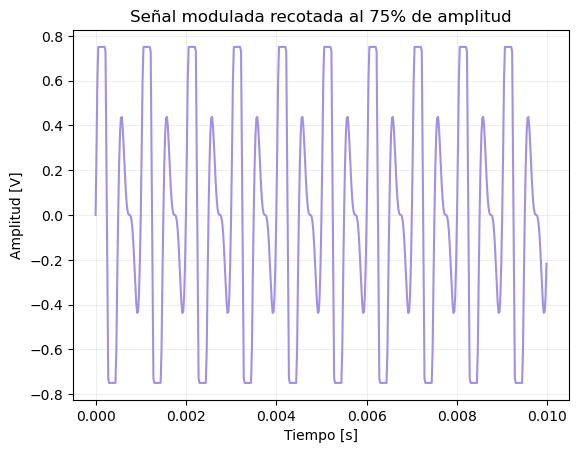

In [8]:
clip_level = 0.75
xx4 = np.clip(xx3, -clip_level, clip_level)
 
P4 = potencia_media(xx4)
print("\n── Señal 4: AM recortada al 75 % (clipping) ──────")
print(f"  Δt          = {TS*1e6:.4f} µs")
print(f"  N muestras  = {N3}  (misma duración que señal 3)")
print(f"  Duración    = {N3*TS*1e3:.2f} ms")
print(f"  Potencia    = {P4:.6f} W ")

plt.plot(tt3, xx4, color='#A390E4')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal modulada recotada al 75% de amplitud")
plt.grid(True, alpha=0.2)

plt.show()

Comparando con la señal modulada sin recortar:

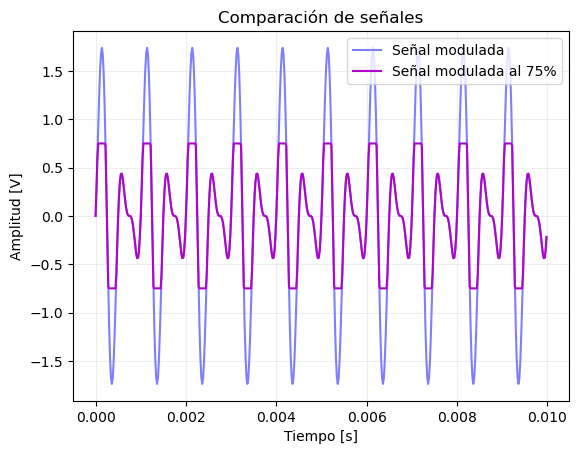

In [9]:

plt.plot(tt3, xx3,color='#7F7EFF', label = 'Señal modulada')
plt.plot(tt3, xx4,color='#AF04CD', label = 'Señal modulada al 75%')
plt.legend()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Comparación de señales")
plt.grid(True, alpha=0.2)

plt.show()

### Una señal cuadrada de 4KHz


── Señal 5: Cuadrada 4 kHz ────────────────────
  Δt          = 20.0000 µs
  N muestras  = 125
  Duración    = 2.50 ms
  Potencia    = 1.000000 W 


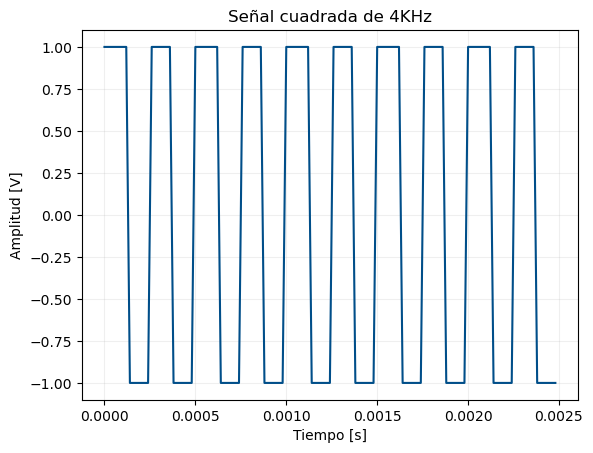

In [10]:
from scipy import signal as sig

ff5 = 4000
N5  = int(10 / ff5 * FS)   # 10 ciclos
tt5 = np.linspace(0, (N5 - 1) * TS, N5)
xx5 = sig.square(2 * np.pi * ff5 * tt5)   # amplitud ±1
 
P5 = potencia_media(xx5)
print("\n── Señal 5: Cuadrada 4 kHz ────────────────────")
print(f"  Δt          = {TS*1e6:.4f} µs")
print(f"  N muestras  = {N5}")
print(f"  Duración    = {N5*TS*1e3:.2f} ms")
print(f"  Potencia    = {P5:.6f} W ")

plt.plot(tt5, xx5, color='#004E89')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuadrada de 4KHz")
plt.grid(True, alpha=0.2)

plt.show()

### Un pulso rectangular de 10ms


── Señal 6: Pulso rectangular 10 ms ──────────
  Δt          = 20.0000 µs
  N muestras  = 1000  (ventana de 20 ms)
  N en pulso  = 500
  Energía     = 0.010020 J
  * Señal de ENERGÍA finita (no de potencia)


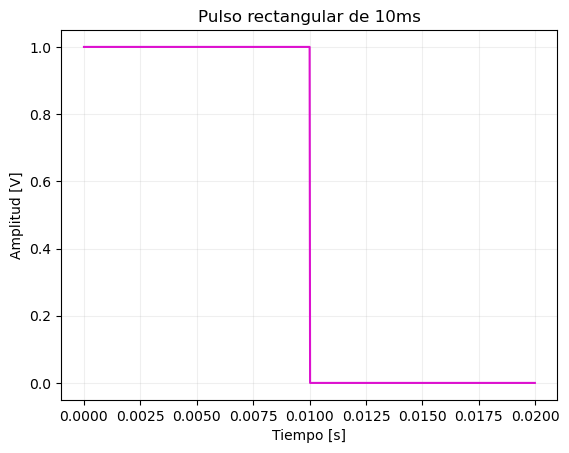

In [11]:
T_ventana = 0.020           # 20 ms de observación
duracion_pulso = 0.010      # 10 ms de duración del pulso
N6 = int(T_ventana * FS)
tt6 = np.linspace(0, (N6 - 1) * TS, N6)
xx6 = np.zeros(N6)
xx6[tt6 <= duracion_pulso] = 1
 
E6 = energia(xx6, TS)
print("\n── Señal 6: Pulso rectangular 10 ms ──────────")
print(f"  Δt          = {TS*1e6:.4f} µs")
print(f"  N muestras  = {N6}  (ventana de {T_ventana*1e3:.0f} ms)")
print(f"  N en pulso  = {int(duracion_pulso*FS)}")
print(f"  Energía     = {E6:.6f} J")
print(f"  * Señal de ENERGÍA finita (no de potencia)")

plt.plot(tt6, xx6, color='#DD10CF')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Pulso rectangular de 10ms")
plt.grid(True, alpha=0.2)

plt.show()

## Resolución ejercicio 2

En esta sección se presentan los gráficos de las convoluciones  $y[n] = x[n] * h[n]$, para los distintos valores de $x[n]$. 

En principio, se plantea el gráfico para $h[n] = \delta[n] - \delta[n - 4]$:

── h[n] = δ[n] - δ[n-4] ──────────────────────
  Valores no nulos en n = [0, 4]
  h[0]  = 1
  h[4]  = -1


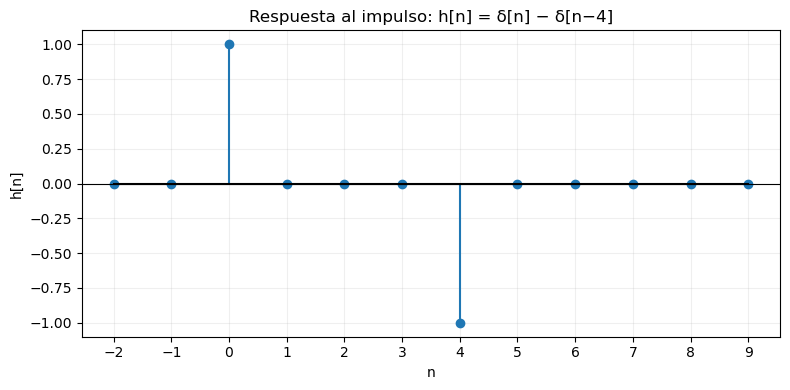

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def delta(n):
    """Delta de Kronecker discreta."""
    return (n == 0).astype(float)

# Rango de n
n = np.arange(-2, 10)

# h[n] = δ[n] - δ[n-4]
h = delta(n) - delta(n - 4)

print("── h[n] = δ[n] - δ[n-4] ──────────────────────")
print(f"  Valores no nulos en n = {n[h != 0].tolist()}")
print(f"  h[0]  = {h[n==0][0]:.0f}")
print(f"  h[4]  = {h[n==4][0]:.0f}")

plt.figure(figsize=(8, 4))
plt.stem(n, h, linefmt='C0-', markerfmt='C0o', basefmt='k-')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(n)
plt.xlabel("n")
plt.ylabel("h[n]")
plt.title("Respuesta al impulso: h[n] = δ[n] − δ[n−4]")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

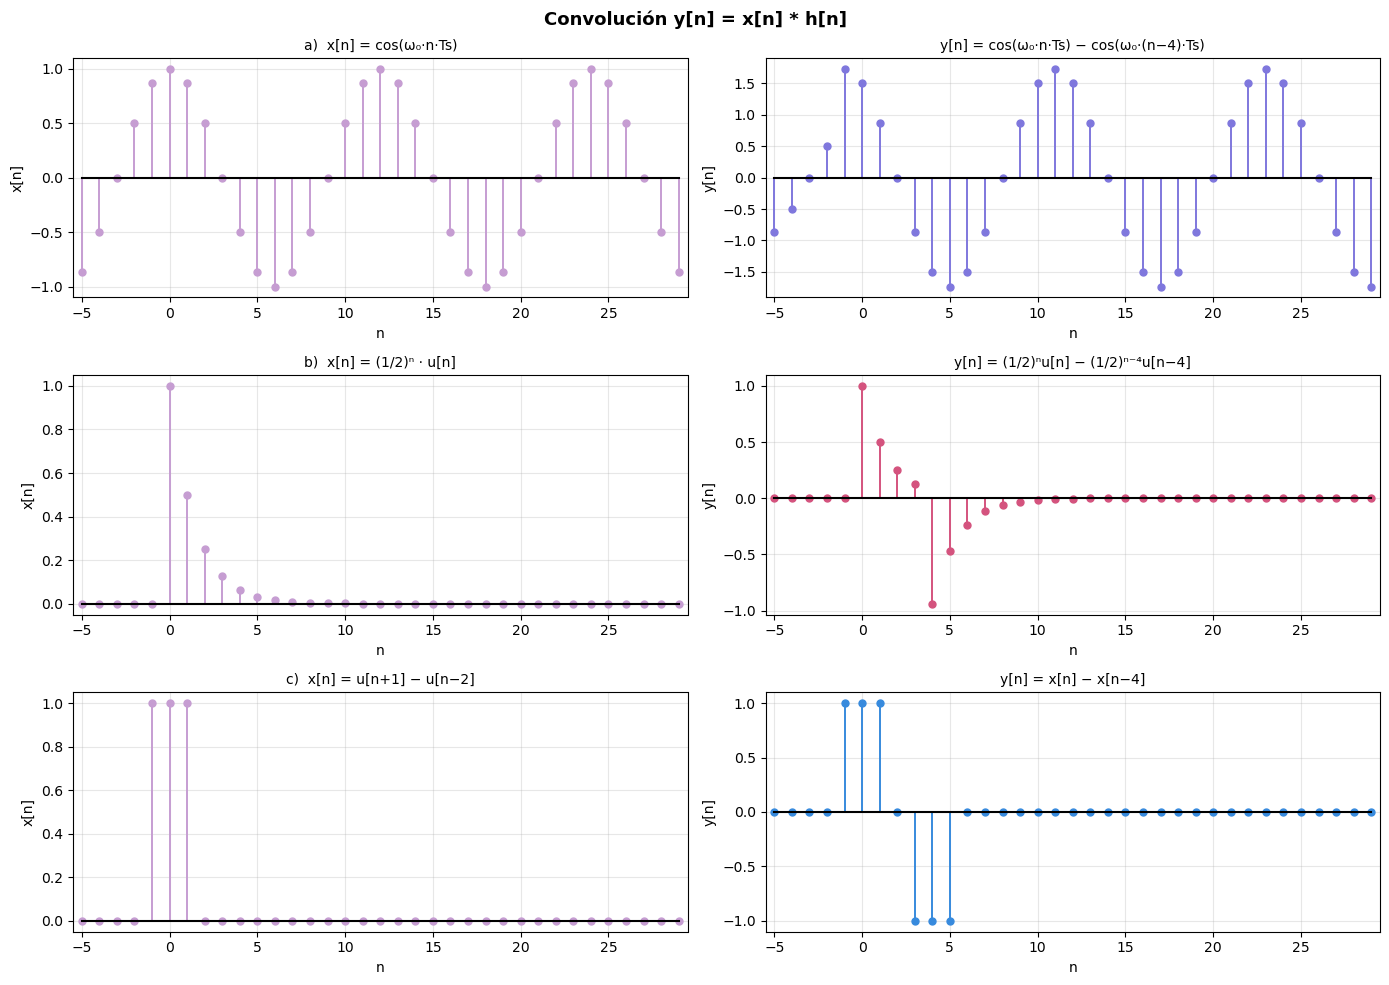

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def delta(n):
    return (n == 0).astype(float)

def u(n):
    return (n >= 0).astype(float)

def delay4(x):
    x_d = np.zeros_like(x)
    x_d[4:] = x[:-4]
    return x_d

n = np.arange(-5, 30)

w0 = np.pi / 6
Ts = 1

x_a = np.cos(w0 * n * Ts)
y_a = x_a - delay4(x_a)

x_b = (0.5 ** n) * u(n)
y_b = x_b - delay4(x_b)

x_c = u(n + 1) - u(n - 2)
y_c = x_c - delay4(x_c)

color_x  = '#C69DD2'
colors_y = ['#7F77DD', '#D4537E', '#378ADD']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Convolución y[n] = x[n] * h[n]", fontsize=13, fontweight='bold')

configs = [
    (x_a, y_a, "a)  x[n] = cos(ω₀·n·Ts)", "y[n] = cos(ω₀·n·Ts) − cos(ω₀·(n−4)·Ts)"),
    (x_b, y_b, "b)  x[n] = (1/2)ⁿ · u[n]", "y[n] = (1/2)ⁿu[n] − (1/2)ⁿ⁻⁴u[n−4]"),
    (x_c, y_c, "c)  x[n] = u[n+1] − u[n−2]", "y[n] = x[n] − x[n−4]"),
]

for i, (x, y, title_x, title_y) in enumerate(configs):
    for ax, data, title, color in zip(
        axes[i],
        [x, y],
        [title_x, title_y],
        [color_x, colors_y[i]]
    ):
        markerline, stemlines, baseline = ax.stem(n, data, linefmt='-', markerfmt='o', basefmt='k-')
        markerline.set_color(color)
        markerline.set_markersize(5)
        stemlines.set_color(color)
        stemlines.set_linewidth(1.4)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("n")
        ax.set_ylabel("x[n]" if ax == axes[i][0] else "y[n]")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(n[0] - 0.5, n[-1] + 0.5)

plt.tight_layout()
plt.show()